# Aufgabe 12.4: Klassifikationsmodell für defekte Flaschen

In diesem Notebook wird ein Klassifikationsmodell erstellt, das anhand der Drop-Vibration vorhersagt, ob eine Flasche defekt ist.

**Zielklasse:** `is_cracked`  
- `0` = intakt  
- `1` = defekt

**Feature-Quelle:** `drop_oscillation`  
Diese Spalte enthält pro Flasche 500 Vibrationswerte als JSON-Array. Daraus werden statistische Kennwerte berechnet, damit scikit-learn die Daten verwenden kann.

## 1. Bibliotheken importieren

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay

## 2. CSV laden

Das Notebook sucht zuerst nach `database/data.csv`. Falls das Notebook direkt neben der CSV liegt, wird alternativ `data.csv` verwendet.

In [3]:

#possible_paths = [
#    Path("database/data.csv"),
#    Path("data.csv"),
#    Path("/mnt/data/data.csv"),  # nur für die Ausführung in dieser ChatGPT-Umgebung
#]

#csv_path = next((path for path in possible_paths if path.exists()), None)

#if csv_path is None:
#    raise FileNotFoundError("data.csv wurde nicht gefunden. Bitte Pfad prüfen.")
csv_path = Path("database/data.csv")

df = pd.read_csv(csv_path)

print("Verwendete Datei:", csv_path)
print("Anzahl Zeilen und Spalten:", df.shape)
df.head()

Verwendete Datei: database\data.csv
Anzahl Zeilen und Spalten: (510, 14)


,bottle,recipe,red_fill_level,blue_fill_level,green_fill_level,red_vibration,blue_vibration,green_vibration,red_temp,blue_temp,green_temp,final_weight,is_cracked,drop_oscillation
0,81740829,7,56.355195,546.578942,492.503147,92.356816,-1.370080,92.509509,34.178723,33.413129,32.952256,24.884694,0,"[""0.0000000000"", ""0.5244412309"", ""0.7645641276..."
1,81740831,7,48.103788,545.091611,484.488770,101.471201,2.225236,91.892157,34.802276,33.404674,36.729803,24.990835,0,"[""0.0000000000"", ""0.5229347540"", ""0.8407549269..."
2,81740833,7,40.798795,543.218725,477.113824,95.118647,11.365305,94.427851,33.417616,33.655806,32.392244,25.096081,0,"[""0.0000000000"", ""0.5759815506"", ""1.6015261906..."
3,81740835,7,33.256828,542.119956,469.731048,102.740527,-7.366184,90.383358,31.987952,31.871362,33.512363,24.527522,0,"[""0.0000000000"", ""0.3562968453"", ""0.6045360191..."
4,81740837,7,26.283345,540.675043,462.840897,89.275574,-1.646569,80.654556,32.490402,35.946574,33.709014,22.961452,0,"[""0.0000000000"", ""0.0048046704"", ""0.0081833030..."


## 3. Zielklasse prüfen

Da defekte Flaschen deutlich seltener sein können als intakte Flaschen, wird die Klassenverteilung kontrolliert. Das ist wichtig für die Interpretation des F1-Scores.

In [4]:
class_counts = df["is_cracked"].value_counts().sort_index()
class_counts.index = ["intakt (0)", "defekt (1)"]
class_counts

intakt (0)    476
defekt (1)     34
Name: count, dtype: int64

## 4. Drop-Oscillation-Daten in numerische Arrays umwandeln

`drop_oscillation` liegt als JSON-Text vor. Dieser Text wird in eine numerische Matrix umgewandelt.

Jede Zeile entspricht einer Flasche, jede Spalte einem Zeitpunkt der Vibrationsmessung.

In [5]:
def parse_drop_oscillation(value):
    """Wandelt die JSON-Liste aus der CSV in ein float-Array um."""
    return np.array(json.loads(value), dtype=float)

oscillation_matrix = np.vstack(df["drop_oscillation"].apply(parse_drop_oscillation))

print("Matrix-Form:", oscillation_matrix.shape)
print("Messwerte pro Flasche:", oscillation_matrix.shape[1])

Matrix-Form: (510, 500)
Messwerte pro Flasche: 500


## 5. Beispiel-Zeitreihen visualisieren

Zur Kontrolle werden einige intakte und defekte Flaschen geplottet.

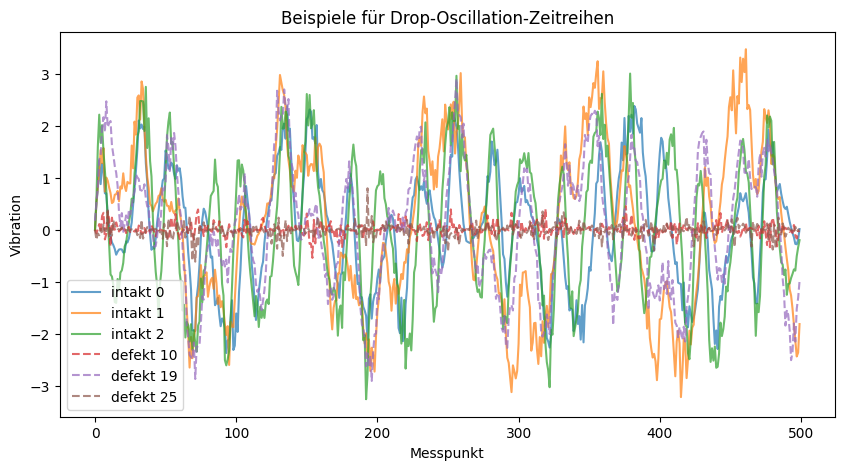

In [9]:
plt.figure(figsize=(10, 5))

intact_indices = df.index[df["is_cracked"] == 0][:3]
cracked_indices = df.index[df["is_cracked"] == 1][:3]

for index in intact_indices:
    plt.plot(oscillation_matrix[index], alpha=0.7, label=f"intakt {index}")

for index in cracked_indices:
    plt.plot(oscillation_matrix[index], alpha=0.7, linestyle="--", label=f"defekt {index}")

plt.title("Beispiele für Drop-Oscillation-Zeitreihen")
plt.xlabel("Messpunkt")
plt.ylabel("Vibration")
plt.legend()
plt.show()

## 6. Features berechnen

Aus jeder Zeitreihe werden einfache statistische Merkmale berechnet. Diese Merkmale dienen später als Eingabe für die Klassifikationsmodelle.

In [10]:
def create_features(matrix):
    """Berechnet statistische Features aus den 500 Vibrationswerten je Flasche."""
    return pd.DataFrame({
        "mean": matrix.mean(axis=1),
        "std": matrix.std(axis=1),
        "max": matrix.max(axis=1),
        "min": matrix.min(axis=1),
        "peak_to_peak": matrix.max(axis=1) - matrix.min(axis=1),
        "rms": np.sqrt(np.mean(matrix ** 2, axis=1)),
        "energy": np.sum(matrix ** 2, axis=1),
        "abs_mean": np.mean(np.abs(matrix), axis=1),
        "diff_std": np.diff(matrix, axis=1).std(axis=1),
        "zero_crossings": np.sum(np.diff(np.signbit(matrix), axis=1), axis=1),
    })

features = create_features(oscillation_matrix)
y = df["is_cracked"].astype(int)

features.head()

,mean,std,max,min,peak_to_peak,rms,energy,abs_mean,diff_std,zero_crossings
0,0.026866,1.106870,2.382784,-2.371065,4.753849,1.107196,612.941961,0.903865,0.328938,40
1,0.101063,1.530952,3.474649,-3.219126,6.693776,1.534284,1177.014457,1.305226,0.363043,15
2,-0.007455,1.372653,3.006127,-3.260485,6.266611,1.372673,942.115550,1.183069,0.457817,39
3,-0.008424,0.939054,2.064824,-2.033487,4.098311,0.939092,440.946510,0.782764,0.251462,20
4,-0.007594,0.108907,0.470510,-0.541705,1.012214,0.109171,5.959160,0.068678,0.162738,264


## 7. Train/Test-Split

Der Datensatz wird in Trainings- und Testdaten aufgeteilt.  
`stratify=y` sorgt dafür, dass das Verhältnis von intakten und defekten Flaschen in beiden Teilmengen ähnlich bleibt.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    features,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Test:", X_test.shape)
print("Klassen im Testdatensatz:")
print(y_test.value_counts().sort_index())

Training: (408, 10)
Test: (102, 10)
Klassen im Testdatensatz:
is_cracked
0    95
1     7
Name: count, dtype: int64


## 8. Feature-Sets und Modelle definieren

Es werden mehrere Feature-Kombinationen getestet. Dadurch entsteht die geforderte F1-Tabelle.

Die logistische Regression verwendet `class_weight="balanced"`, weil die Klasse `defekt` seltener vorkommt.

In [12]:
feature_sets = {
    "mean()": ["mean"],
    "mean(), std()": ["mean", "std"],
    "mean(), std(), max(), min()": ["mean", "std", "max", "min"],
    "mean(), std(), max(), min(), peak_to_peak(), rms()": [
        "mean", "std", "max", "min", "peak_to_peak", "rms"
    ],
    "alle berechneten Features": [
        "mean", "std", "max", "min", "peak_to_peak", "rms",
        "energy", "abs_mean", "diff_std", "zero_crossings"
    ],
}

models = {
    "Log. Regression": make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
    ),
    "kNN": make_pipeline(
        StandardScaler(),
        KNeighborsClassifier(n_neighbors=5)
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ),
}

## 9. Modelle trainieren und F1-Scores berechnen

Der F1-Score ist für diese Aufgabe sinnvoll, weil er Precision und Recall kombiniert.  
Hier wird der F1-Score für die Klasse `1 = defekt` berechnet.

In [13]:
results = []
trained_models = {}

for feature_set_name, selected_features in feature_sets.items():
    for model_name, model in models.items():
        model.fit(X_train[selected_features], y_train)

        y_train_pred = model.predict(X_train[selected_features])
        y_test_pred = model.predict(X_test[selected_features])

        f1_train = f1_score(y_train, y_train_pred, pos_label=1, zero_division=0)
        f1_test = f1_score(y_test, y_test_pred, pos_label=1, zero_division=0)

        results.append({
            "Genutzte Features": feature_set_name,
            "Modell-Typ": model_name,
            "F1-Score (Training)": f1_train,
            "F1-Score (Test)": f1_test,
        })

        trained_models[(feature_set_name, model_name)] = model

results_df = pd.DataFrame(results)
results_df = results_df.sort_values("F1-Score (Test)", ascending=False).reset_index(drop=True)
results_df

,Genutzte Features,Modell-Typ,F1-Score (Training),F1-Score (Test)
0,"mean(), std()",Random Forest,0.915254,0.750000
1,"mean(), std(), max(), min()",Random Forest,0.931034,0.666667
2,alle berechneten Features,Random Forest,0.915254,0.625000
3,"mean(), std(), max(), min(), peak_to_peak(), r...",Random Forest,0.931034,0.615385
4,alle berechneten Features,Log. Regression,0.287425,0.378378
5,"mean(), std(), max(), min(), peak_to_peak(), r...",kNN,0.512821,0.250000
6,"mean(), std()",Log. Regression,0.170455,0.227273
7,alle berechneten Features,kNN,0.500000,0.222222
8,"mean(), std(), max(), min()",Log. Regression,0.153005,0.146341
9,"mean(), std(), max(), min(), peak_to_peak(), r...",Log. Regression,0.146597,0.142857


## 10. Beste Variante auswählen

Für die Confusion Matrix wird automatisch die Variante mit dem höchsten F1-Score auf den Testdaten verwendet.

In [22]:
best_row = results_df.iloc[0]
best_feature_set_name = best_row["Genutzte Features"]
best_model_name = best_row["Modell-Typ"]
best_features = feature_sets[best_feature_set_name]
best_model = trained_models[(best_feature_set_name, best_model_name)]

print("Beste Variante:")
print("Features:", best_feature_set_name)
print("Modell:", best_model_name)
print("F1-Score Test:", round(best_row["F1-Score (Test)"], 4))

Beste Variante:
Features: mean(), std()
Modell: Random Forest
F1-Score Test: 0.75


## 11. Confusion Matrix

Die Confusion Matrix zeigt, wie viele Flaschen korrekt oder falsch als intakt bzw. defekt klassifiziert wurden.

In [26]:
print(best_model.feature_names_in_)
print(X_test[best_features].columns)

['mean' 'std' 'max' 'min' 'peak_to_peak' 'rms' 'energy' 'abs_mean'
 'diff_std' 'zero_crossings']
Index(['mean', 'std'], dtype='object')


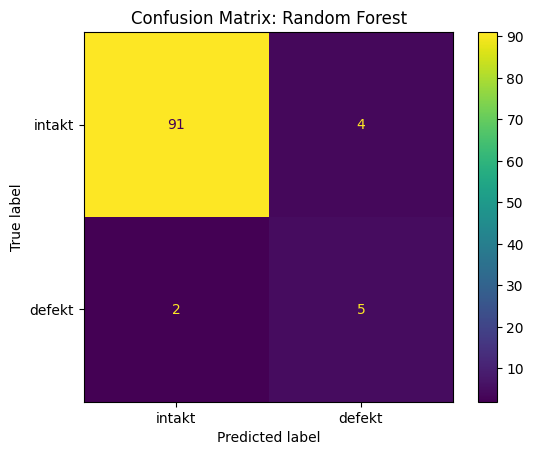

[[91  4]
 [ 2  5]]


In [27]:
best_features = list(best_model.feature_names_in_)

y_test_pred_best = best_model.predict(X_test[best_features])

cm = confusion_matrix(
    y_test,
    y_test_pred_best,
    labels=[0, 1]
)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["intakt", "defekt"]
).plot()

plt.title(f"Confusion Matrix: {best_model_name}")
plt.show()

print(cm)

## 12. Kurze Interpretation

Die Tabelle zeigt, welche Feature-Kombinationen und Modelle auf den Testdaten den höchsten F1-Score erreichen. Da im Datensatz deutlich weniger defekte als intakte Flaschen enthalten sind, ist die Klassifikation der defekten Flaschen schwieriger als die Klassifikation der intakten Flaschen.